# Stage 1 Fill — Mem0 Results (PersonaMEM2)

This notebook analyses the **stage 1 fill** benchmark: each run processes one user’s message bundle, extracts memories, and calls the Mem0 add API. The goal is to understand **reliability** (success vs failure), **per-user load** (messages, time, tokens), and **graph usage** (how many runs used the graph and what graph-related errors occurred).

In [1]:
import json

In [2]:
STAGE_1_PATH = "benchmark_logs/multi_gpt-4.1-mini_graph_2try/stage_1/stage1_RUN-1_fill_20260309_223505.json"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.size"] = 10

with open(STAGE_1_PATH) as f:
    data = json.load(f)

df = pd.DataFrame(data["per_user"])
# Summary stats
n_users = len(df)
n_success = df["success"].sum()
n_fail = n_users - n_success
print("=== Stage 1 Fill — Summary ===")
print(f"Users: {n_users}  |  Success: {n_success}  |  Failed: {n_fail}  |  Success rate: {100 * n_success / n_users:.1f}%")
print(f"Total wall time: {data['total_wall_seconds'] / 3600:.2f} h  |  Total add_calls: {data['total_add_calls']}")
print(f"Total input tokens: {data['total_input_tokens']:,}")
print()
print("Per-user (wall_seconds):", df["wall_seconds"].describe().round(2).to_string())
print()
print("Per-user (num_messages):", df["num_messages"].describe().round(2).to_string())
print()
print("Per-user (input_tokens):", df["input_tokens"].describe().round(0).to_string())

=== Stage 1 Fill — Summary ===
Users: 195  |  Success: 179  |  Failed: 16  |  Success rate: 91.8%
Total wall time: 5.14 h  |  Total add_calls: 179
Total input tokens: 6,161,067

Per-user (wall_seconds): count    195.00
mean      94.83
std       59.42
min       22.32
25%       49.48
50%       76.13
75%      121.24
max      274.56

Per-user (num_messages): count    195.00
mean     233.42
std       23.52
min      162.00
25%      220.00
50%      234.00
75%      249.00
max      293.00

Per-user (input_tokens): count      195.0
mean     31595.0
std       1208.0
min      24045.0
25%      31742.0
50%      31894.0
75%      32014.0
max      34222.0


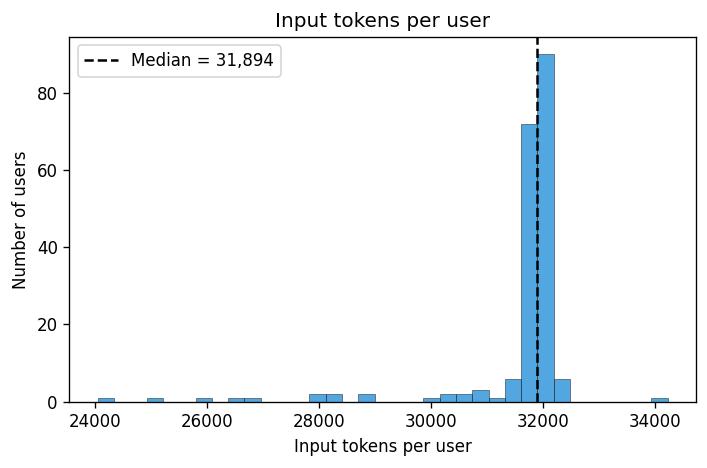

In [4]:
# Input tokens per user (standalone plot)
import json
import statistics
import matplotlib.pyplot as plt
with open(STAGE_1_PATH) as f:
    data = json.load(f)
per_user = data["per_user"]
tokens = [u["input_tokens"] for u in per_user]
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.hist(tokens, bins=min(35, max(10, len(tokens) // 5)), color="#3498db", alpha=0.85, edgecolor="black", linewidth=0.3)
med = statistics.median(tokens)
ax.axvline(med, color="black", linestyle="--", linewidth=1.5, label=f"Median = {med:,.0f}")
ax.set_xlabel("Input tokens per user")
ax.set_ylabel("Number of users")
ax.set_title("Input tokens per user")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def categorize_error(err):
    if err is None or pd.isna(err):
        return "—"
    s = str(err).strip()
    if "Unterminated string" in s:
        return "Unterminated string (JSON parse)"
    if "'destination'" in s:
        return "KeyError: 'destination'"
    if "Error code: 500" in s or "server_error" in s:
        return "Server error (500)"
    if "lower'" in s or "has no attribute" in s:
        return "AttributeError (e.g. .lower)"
    if "NoneType" in s or "not subscriptable" in s:
        return "NoneType / subscript"
    return "Other"

df["error_category"] = df["error"].map(categorize_error)
failed = df[~df["success"]]
error_counts = failed["error_category"].value_counts()
print("Error breakdown (failed users only):")
print(error_counts.to_string())
print()

# Graph usage and graph errors (same categorization as main error)
df["graph_error_category"] = df["graph_error"].map(categorize_error)
n_used_graph = df["used_graph"].sum()
n_no_graph = len(df) - n_used_graph
with_graph_error = df[df["graph_error"].notna() & (df["graph_error"].astype(str).str.len() > 0)]
graph_error_counts = with_graph_error["graph_error_category"].value_counts()
print("Graph usage: used_graph=True:", int(n_used_graph), "| used_graph=False:", int(n_no_graph))
print("Graph errors (runs with non-null graph_error):", len(with_graph_error))
if len(graph_error_counts) > 0:
    print(graph_error_counts.to_string())

Error breakdown (failed users only):
error_category
Unterminated string (JSON parse)    13
Other                                3

Graph usage: used_graph=True: 195 | used_graph=False: 0
Graph errors (runs with non-null graph_error): 53
graph_error_category
Unterminated string (JSON parse)    39
Other                                7
KeyError: 'destination'              4
AttributeError (e.g. .lower)         3


In [6]:
# Plot style: professional, minimal, publication-ready
FIG_KW = {"figsize": (6, 4), "dpi": 120}
COLORS = {"success": "#2ecc71", "fail": "#e74c3c", "neutral": "#3498db", "graph": "#9b59b6"}
plt.rc("axes", titlesize=11, titleweight="bold")
plt.rc("axes", linewidth=0.8)

## Outcome: success vs failure

Whether each user run completed without raising an error. Failures are analysed by error type below.

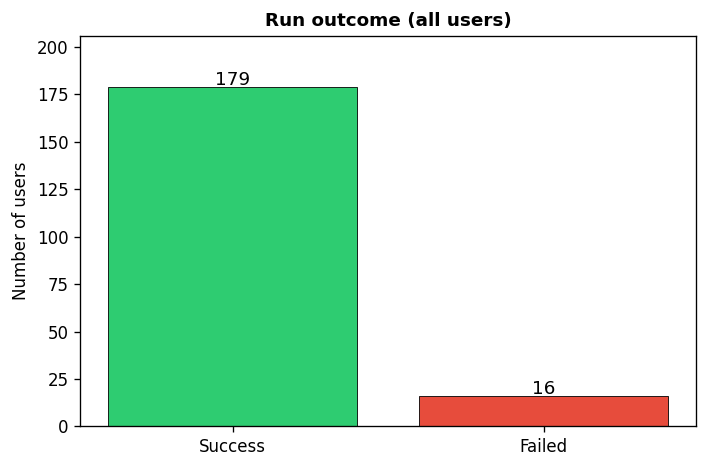

In [7]:
# Success vs failure
fig, ax = plt.subplots(**FIG_KW)
counts = [n_success, n_fail]
labels = ["Success", "Failed"]
colors = [COLORS["success"], COLORS["fail"]]
bars = ax.bar(labels, counts, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Number of users")
ax.set_title("Run outcome (all users)")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, str(int(b.get_height())), ha="center", fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

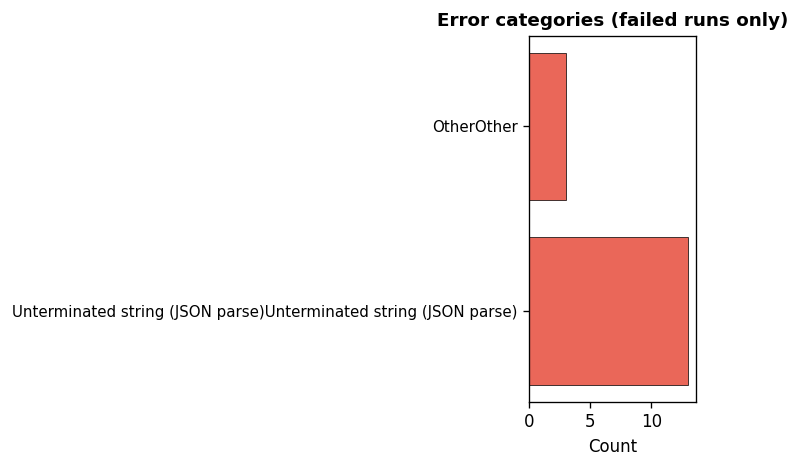

In [8]:
# 2. Error type breakdown (failed users only)
if len(error_counts) > 0:
    fig, ax = plt.subplots(**FIG_KW)
    err_labels = [e[:40] + ("…" if len(e) > 40 else e) for e in error_counts.index]
    ax.barh(range(len(error_counts)), error_counts.values, color=COLORS["fail"], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(error_counts)))
    ax.set_yticklabels(err_labels, fontsize=9)
    ax.set_xlabel("Count")
    ax.set_title("Error categories (failed runs only)")
    plt.tight_layout()
    plt.show()
else:
    print("No failed runs — no error breakdown.")

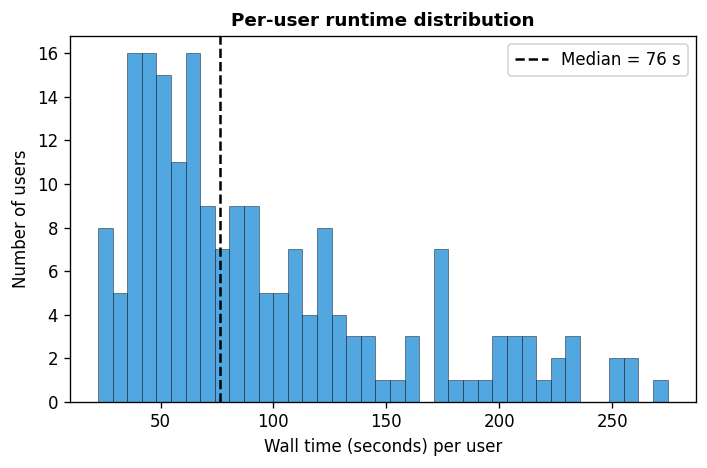

In [9]:
# 2. Wall time (seconds) per user
fig, ax = plt.subplots(**FIG_KW)
ax.hist(df["wall_seconds"], bins=min(40, max(10, n_users // 5)), color=COLORS["neutral"], alpha=0.85, edgecolor="black", linewidth=0.3)
med = df["wall_seconds"].median()
ax.axvline(med, color="black", linestyle="--", linewidth=1.5, label=f"Median = {med:.0f} s")
ax.set_xlabel("Wall time (seconds) per user")
ax.set_ylabel("Number of users")
ax.set_title("Per-user runtime distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 2. Wall time (seconds) per user

Real time spent processing each user. High variance may indicate retries, API latency, or message-volume effects.

## Per-user metrics

Each point is one user. Below: **message count**, **runtime**, and **input tokens** per user (for capacity planning and outliers).

### 1. Number of messages per user

Conversation size (message count) per user. Drives context length and processing time.

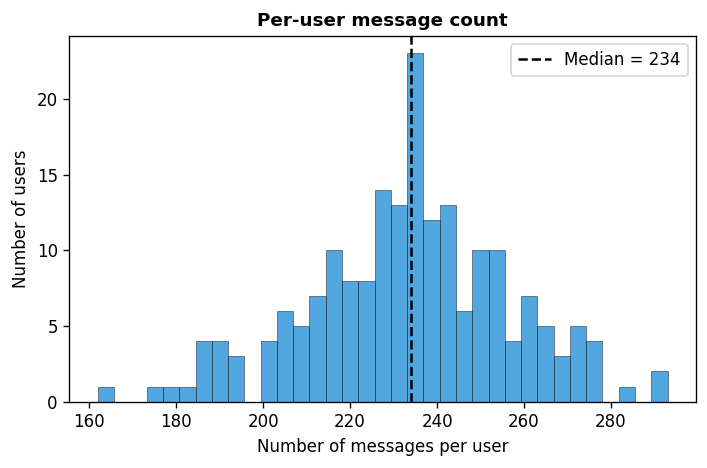

In [10]:
# 1. Number of messages per user
fig, ax = plt.subplots(**FIG_KW)
ax.hist(df["num_messages"], bins=min(35, max(12, n_users // 5)), color=COLORS["neutral"], alpha=0.85, edgecolor="black", linewidth=0.3)
med_msg = df["num_messages"].median()
ax.axvline(med_msg, color="black", linestyle="--", linewidth=1.5, label=f"Median = {med_msg:.0f}")
ax.set_xlabel("Number of messages per user")
ax.set_ylabel("Number of users")
ax.set_title("Per-user message count")
ax.legend()
plt.tight_layout()
plt.show()

### Wall time by outcome (success vs failed)

Box plot comparison: whether failed runs tend to be slower or faster than successful ones.

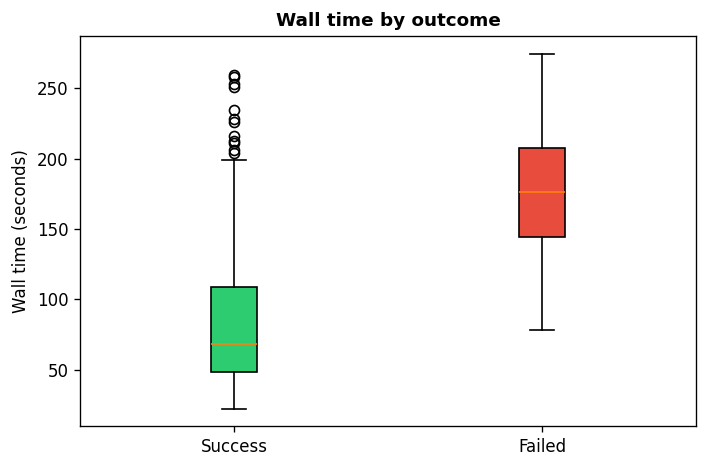

In [11]:
# 4. Wall time by success/failure (box plot)
fig, ax = plt.subplots(**FIG_KW)
success_vals = df[df["success"]]["wall_seconds"]
fail_vals = df[~df["success"]]["wall_seconds"]
bp = ax.boxplot([success_vals, fail_vals], tick_labels=["Success", "Failed"], patch_artist=True)
bp["boxes"][0].set_facecolor(COLORS["success"])
bp["boxes"][1].set_facecolor(COLORS["fail"])
ax.set_ylabel("Wall time (seconds)")
ax.set_title("Wall time by outcome")
plt.tight_layout()
plt.show()

## Relationships and add-calls

**Messages vs wall time:** Shows whether higher message count correlates with longer runtime; failures are marked with crosses. **Add calls:** Number of Mem0 add API invocations per user (batching behaviour).

### 3. Input tokens per user

Tokens sent to the model per user. Relevant for cost and context-window limits.

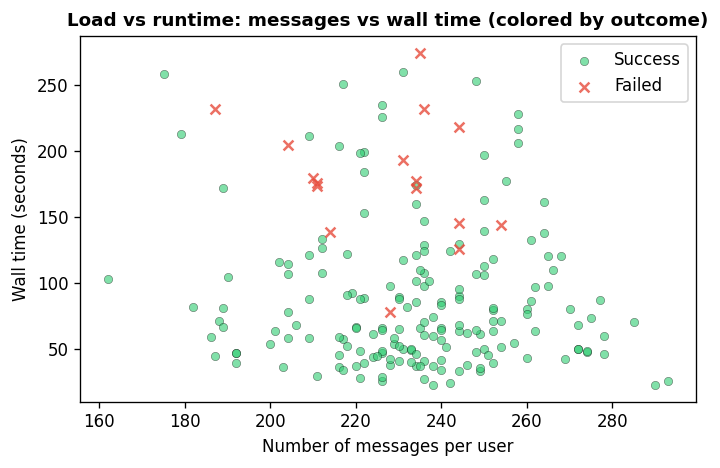

In [12]:
# Messages vs wall time (by outcome)
fig, ax = plt.subplots(**FIG_KW)
ax.scatter(df[df["success"]]["num_messages"], df[df["success"]]["wall_seconds"], c=COLORS["success"], alpha=0.6, s=25, label="Success", edgecolors="black", linewidth=0.3)
ax.scatter(df[~df["success"]]["num_messages"], df[~df["success"]]["wall_seconds"], c=COLORS["fail"], alpha=0.8, s=35, label="Failed", marker="x", linewidths=1.5)
ax.set_xlabel("Number of messages per user")
ax.set_ylabel("Wall time (seconds)")
ax.set_title("Load vs runtime: messages vs wall time (colored by outcome)")
ax.legend()
plt.tight_layout()
plt.show()

## Graph usage and graph errors

Runs can use a graph backend (`used_graph=True`). This section shows how many runs used the graph and how many reported a non-null `graph_error` (including runs that may still have succeeded overall).

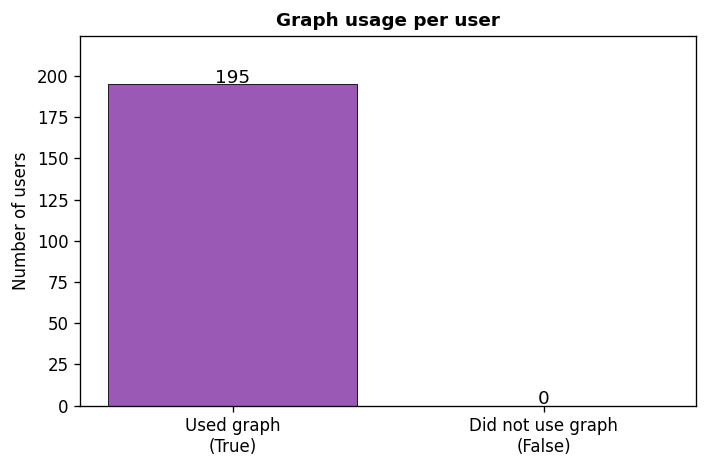

In [13]:
# How many used graph
fig, ax = plt.subplots(**FIG_KW)
counts = [int(n_used_graph), int(n_no_graph)]
labels = ["Used graph\n(True)", "Did not use graph\n(False)"]
colors = [COLORS["graph"], "#95a5a6"]
bars = ax.bar(labels, counts, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Number of users")
ax.set_title("Graph usage per user")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, str(int(b.get_height())), ha="center", fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

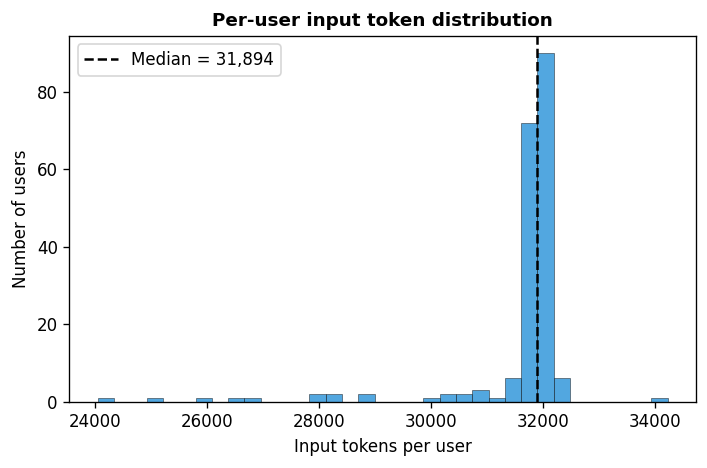

In [14]:
# 3. Input tokens per user
fig, ax = plt.subplots(**FIG_KW)
ax.hist(df["input_tokens"], bins=min(35, max(10, n_users // 5)), color=COLORS["neutral"], alpha=0.85, edgecolor="black", linewidth=0.3)
med_tok = df["input_tokens"].median()
ax.axvline(med_tok, color="black", linestyle="--", linewidth=1.5, label=f"Median = {med_tok:,.0f}")
ax.set_xlabel("Input tokens per user")
ax.set_ylabel("Number of users")
ax.set_title("Per-user input token distribution")
ax.legend()
plt.tight_layout()
plt.show()

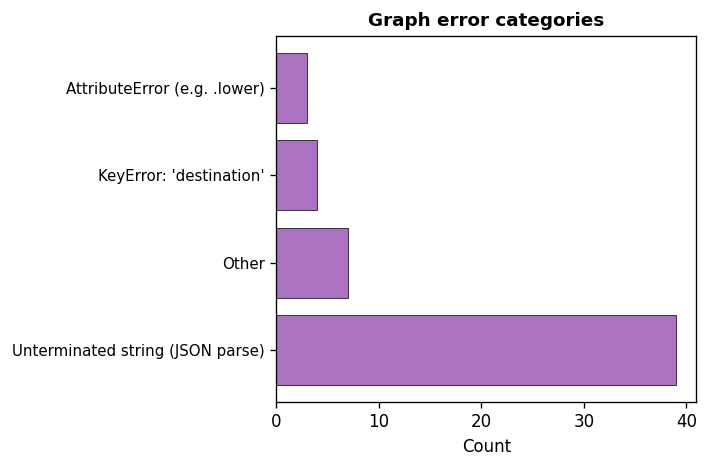

In [15]:
# Graph errors (runs with non-null graph_error)
if len(graph_error_counts) > 0:
    fig, ax = plt.subplots(**FIG_KW)
    glabels = [str(e)[:42] + ("…" if len(str(e)) > 42 else "") for e in graph_error_counts.index]
    ax.barh(range(len(graph_error_counts)), graph_error_counts.values, color=COLORS["graph"], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(graph_error_counts)))
    ax.set_yticklabels(glabels, fontsize=9)
    ax.set_xlabel("Count")
    ax.set_title("Graph error categories")
    plt.tight_layout()
    plt.show()
else:
    print("No graph errors recorded (all graph_error values null or empty).")

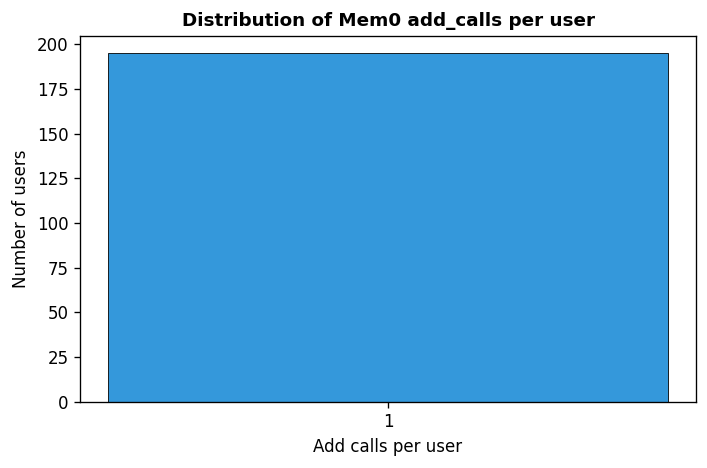

In [16]:
# Add calls per user (Mem0 add API invocations)
add_counts = df["add_calls"].value_counts().sort_index()
fig, ax = plt.subplots(**FIG_KW)
ax.bar(add_counts.index.astype(str), add_counts.values, color=COLORS["neutral"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("Add calls per user")
ax.set_ylabel("Number of users")
ax.set_title("Distribution of Mem0 add_calls per user")
plt.tight_layout()
plt.show()

## Plot summary

| Plot | Purpose |
|------|--------|
| **Success vs failure** | Overall reliability (count of successful vs failed user runs). |
| **Error categories** | Root-cause breakdown for failed runs (JSON parse, API, code errors). |
| **Per-user: num messages** | Distribution of conversation size per user; drives context length and runtime. |
| **Per-user: wall time** | Distribution of runtime per user; median and spread for capacity planning. |
| **Per-user: input tokens** | Token usage per user; cost and context-window planning. |
| **Wall time by outcome** | Compare duration of successful vs failed runs. |
| **Graph usage** | How many runs used the graph backend (used_graph True vs False). |
| **Graph errors** | Breakdown of graph_error types (non-null); same taxonomy as main errors. |
| **Messages vs wall time** | Load vs runtime; failures marked; check for correlation and clustering. |
| **Add calls** | Mem0 add API invocations per user (batching behaviour). |
| **Throughput (tokens/min)** | Do failed runs use more time per token (retries) or crash early? |
| **Tokens per message** | Context density; outliers may need batching/truncation. |
| **Success by message quartile** | Do longer conversations fail more often? |
| **Wall time vs tokens** | Is runtime linear in load? Where do failures sit? |
| **Tail latency (P50–P99)** | How bad is the slowest 1% / 5% / 10%? |
| **Graph error vs success** | Non-fatal graph errors (success despite graph_error)? |
| **Run order vs wall time** | Do failures cluster by user_id (e.g. resource exhaustion)? |

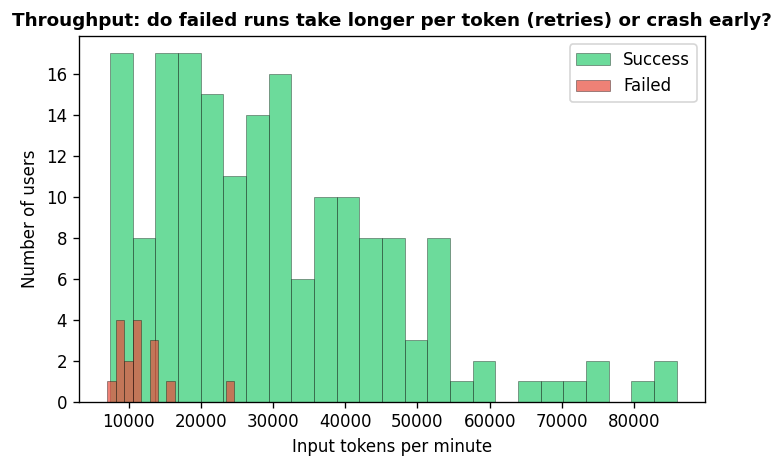

In [17]:
# 1. Throughput: tokens per minute (are failures slower or faster?)
df["tokens_per_min"] = df["input_tokens"] / (df["wall_seconds"] / 60)
fig, ax = plt.subplots(**FIG_KW)
ax.hist(df[df["success"]]["tokens_per_min"], bins=25, color=COLORS["success"], alpha=0.7, label="Success", edgecolor="black", linewidth=0.3)
ax.hist(df[~df["success"]]["tokens_per_min"], bins=15, color=COLORS["fail"], alpha=0.7, label="Failed", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Input tokens per minute")
ax.set_ylabel("Number of users")
ax.set_title("Throughput: do failed runs take longer per token (retries) or crash early?")
ax.legend()
plt.tight_layout()
plt.show()

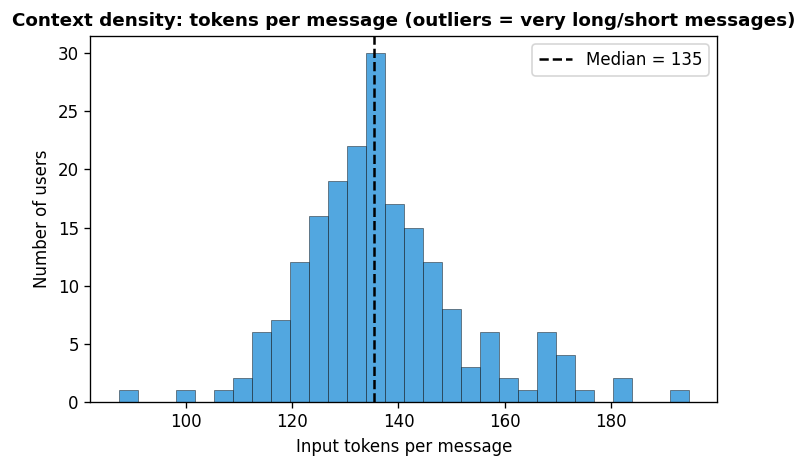

In [18]:
# 2. Tokens per message (context density) — outliers may need batching or truncation
df["tokens_per_message"] = df["input_tokens"] / df["num_messages"]
fig, ax = plt.subplots(**FIG_KW)
ax.hist(df["tokens_per_message"], bins=30, color=COLORS["neutral"], alpha=0.85, edgecolor="black", linewidth=0.3)
ax.axvline(df["tokens_per_message"].median(), color="black", linestyle="--", linewidth=1.5, label=f"Median = {df['tokens_per_message'].median():.0f}")
ax.set_xlabel("Input tokens per message")
ax.set_ylabel("Number of users")
ax.set_title("Context density: tokens per message (outliers = very long/short messages)")
ax.legend()
plt.tight_layout()
plt.show()

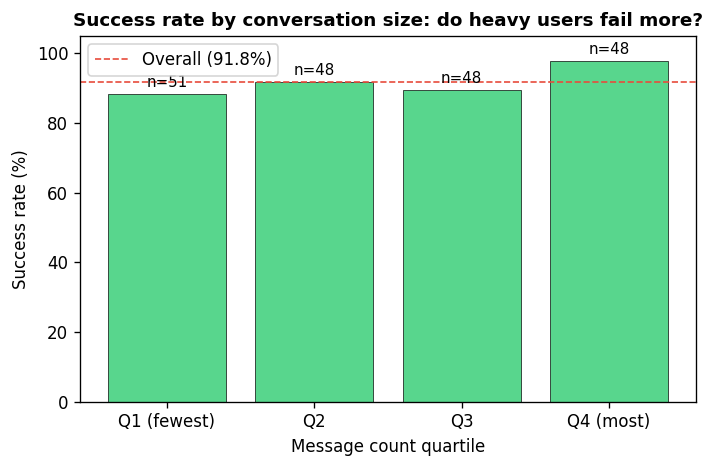

In [19]:
# 3. Success rate by message-count quartile (do longer conversations fail more?)
df["msg_quartile"] = pd.qcut(df["num_messages"], q=4, labels=["Q1 (fewest)", "Q2", "Q3", "Q4 (most)"])
qr = df.groupby("msg_quartile", observed=True).agg(success_rate=("success", "mean"), count=("success", "count")).reset_index()
fig, ax = plt.subplots(**FIG_KW)
ax.bar(qr["msg_quartile"].astype(str), 100 * qr["success_rate"], color=COLORS["success"], alpha=0.8, edgecolor="black", linewidth=0.5)
ax.axhline(100 * n_success / n_users, color=COLORS["fail"], linestyle="--", linewidth=1, label=f"Overall ({100*n_success/n_users:.1f}%)")
for i, row in qr.iterrows():
    ax.text(i, 100 * row["success_rate"] + 2, f"n={int(row['count'])}", ha="center", fontsize=9)
ax.set_ylabel("Success rate (%)")
ax.set_xlabel("Message count quartile")
ax.set_title("Success rate by conversation size: do heavy users fail more?")
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

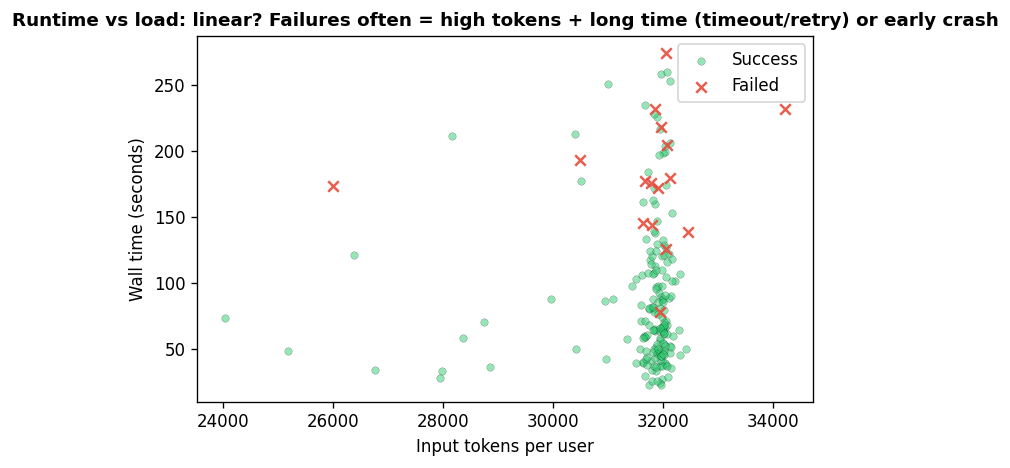

In [20]:
# 4. Wall time vs input tokens (linear? where do failures sit?)
fig, ax = plt.subplots(**FIG_KW)
ax.scatter(df[df["success"]]["input_tokens"], df[df["success"]]["wall_seconds"], c=COLORS["success"], alpha=0.5, s=20, label="Success", edgecolors="black", linewidth=0.2)
ax.scatter(df[~df["success"]]["input_tokens"], df[~df["success"]]["wall_seconds"], c=COLORS["fail"], alpha=0.9, s=40, marker="x", linewidths=1.5, label="Failed")
ax.set_xlabel("Input tokens per user")
ax.set_ylabel("Wall time (seconds)")
ax.set_title("Runtime vs load: linear? Failures often = high tokens + long time (timeout/retry) or early crash")
plt.legend()
plt.tight_layout()
plt.show()

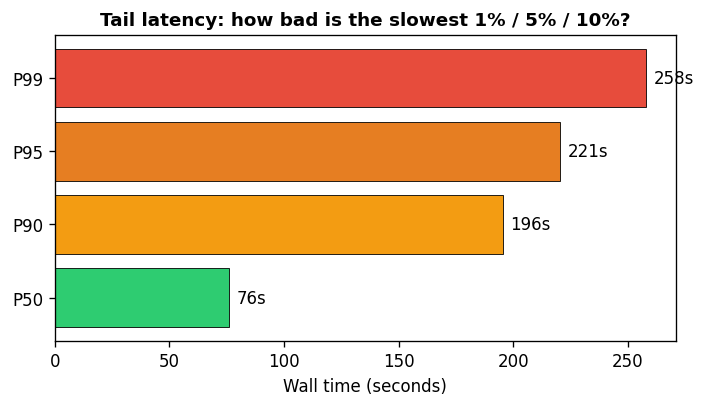

In [21]:
# 5. Tail latency: P50, P90, P95, P99 wall time (seconds)
p50, p90, p95, p99 = df["wall_seconds"].quantile([0.5, 0.9, 0.95, 0.99])
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=120)
percentiles = ["P50", "P90", "P95", "P99"]
vals = [p50, p90, p95, p99]
colors = [COLORS["success"], "#f39c12", "#e67e22", COLORS["fail"]]
bars = ax.barh(percentiles, vals, color=colors, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, vals):
    ax.text(v + 3, b.get_y() + b.get_height() / 2, f"{v:.0f}s", va="center", fontsize=10)
ax.set_xlabel("Wall time (seconds)")
ax.set_title("Tail latency: how bad is the slowest 1% / 5% / 10%?")
plt.tight_layout()
plt.show()

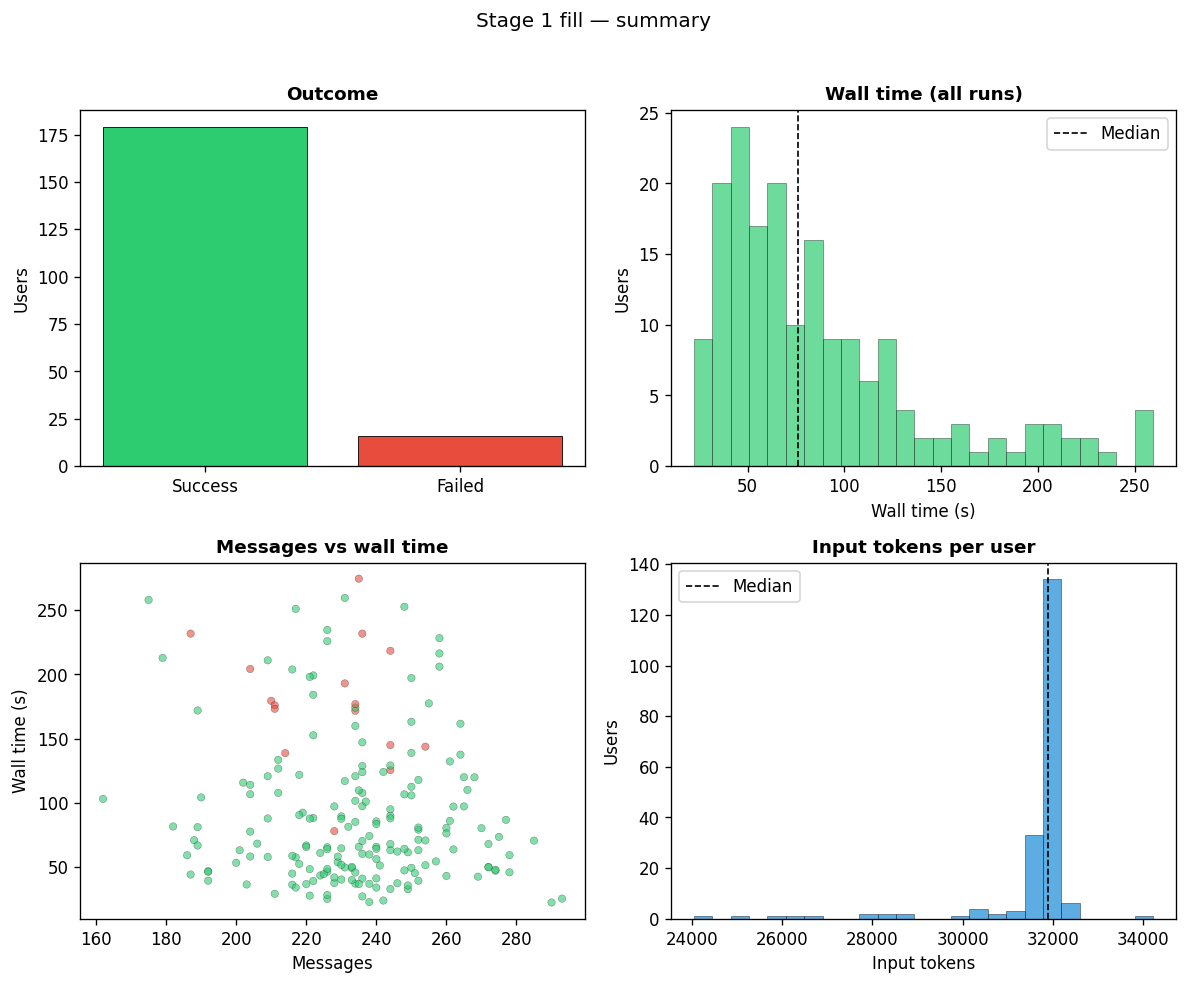

In [22]:
# 8. Summary figure (2×2) for reports
fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=120)
# Top-left: success/fail
ax = axes[0, 0]
ax.bar(["Success", "Failed"], [n_success, n_fail], color=[COLORS["success"], COLORS["fail"]], edgecolor="black", linewidth=0.5)
ax.set_ylabel("Users")
ax.set_title("Outcome")
# Top-right: wall time histogram (success only for clarity)
ax = axes[0, 1]
ax.hist(df[df["success"]]["wall_seconds"], bins=25, color=COLORS["success"], alpha=0.7, edgecolor="black", linewidth=0.3)
ax.axvline(df["wall_seconds"].median(), color="black", linestyle="--", linewidth=1, label="Median")
ax.set_xlabel("Wall time (s)")
ax.set_ylabel("Users")
ax.set_title("Wall time (all runs)")
ax.legend()
# Bottom-left: messages vs wall time
ax = axes[1, 0]
ax.scatter(df["num_messages"], df["wall_seconds"], c=df["success"].map({True: COLORS["success"], False: COLORS["fail"]}), alpha=0.6, s=20, edgecolors="black", linewidth=0.2)
ax.set_xlabel("Messages")
ax.set_ylabel("Wall time (s)")
ax.set_title("Messages vs wall time")
# Bottom-right: input tokens
ax = axes[1, 1]
ax.hist(df["input_tokens"], bins=25, color=COLORS["neutral"], alpha=0.8, edgecolor="black", linewidth=0.3)
ax.axvline(df["input_tokens"].median(), color="black", linestyle="--", linewidth=1, label="Median")
ax.set_xlabel("Input tokens")
ax.set_ylabel("Users")
ax.set_title("Input tokens per user")
ax.legend()
plt.suptitle("Stage 1 fill — summary", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

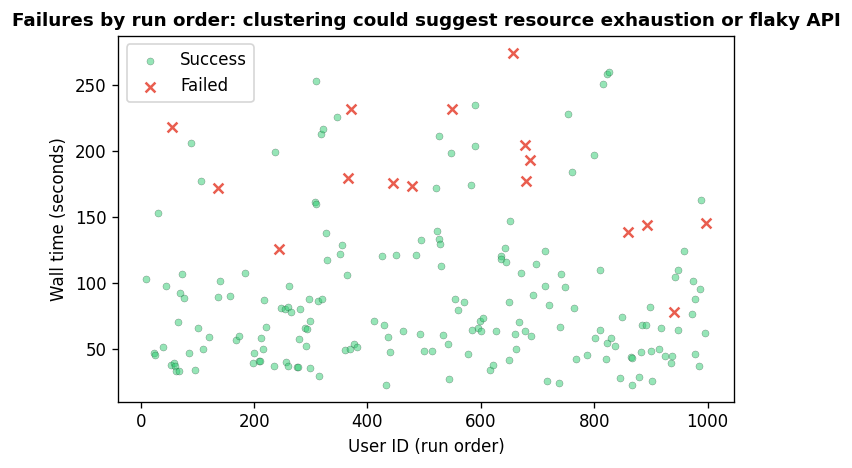

In [23]:
# 7. Run order (user_id) vs wall time — do failures cluster by processing order?
fig, ax = plt.subplots(**FIG_KW)
ax.scatter(df[df["success"]]["user_id"], df[df["success"]]["wall_seconds"], c=COLORS["success"], alpha=0.5, s=18, label="Success", edgecolors="black", linewidth=0.2)
ax.scatter(df[~df["success"]]["user_id"], df[~df["success"]]["wall_seconds"], c=COLORS["fail"], alpha=0.9, s=35, marker="x", linewidths=1.5, label="Failed")
ax.set_xlabel("User ID (run order)")
ax.set_ylabel("Wall time (seconds)")
ax.set_title("Failures by run order: clustering could suggest resource exhaustion or flaky API")
ax.legend()
plt.tight_layout()
plt.show()